# LeetCode #136: Single Number

https://leetcode.com/problems/single-number/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (sort and scan)** | $O(n \log n)$ | $O(1)$ |
| **Hash Map (count occurrences)** | $O(n)$ | $O(n)$ |
| **Optimal: XOR ★** | $O(n)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force (sort and scan)
Sort the array, then scan pairs. Adjacent equal elements are duplicates; an unpaired element stands alone. $O(n \log n)$ time and modifies the array.

### Hash Map (count occurrences)
Record each element's count in a hash map, return the key with count 1. $O(n)$ time but $O(n)$ space for the map.

### Optimal: XOR ★
XOR every element together. Duplicate pairs cancel: $a \oplus a = 0$. XOR with 0 is identity: $a \oplus 0 = a$. Order doesn't matter. Result is the single unique element.

**Why this is better than Hash Map:** $O(1)$ space — no auxiliary data structure, single linear scan.

**Constraints:**
* $1 \le$ nums.length $\le 3 \times 10^4$
* $-3 \times 10^4 \le$ nums[i] $\le 3 \times 10^4$
* Each element appears exactly twice except for one element which appears exactly once.

## Solutions

### C#

In [ ]:
public int SingleNumber(int[] nums) {
    // XOR all elements: pairs cancel to 0, single element survives
    return nums.Aggregate(0, (acc, n) => acc ^ n);
}

### Python

In [ ]:
from functools import reduce
from operator import xor

def singleNumber(self, nums: List[int]) -> int:
    # XOR all elements: pairs cancel to 0, single element survives
    return reduce(xor, nums)

### Go

In [ ]:
func singleNumber(nums []int) int {
    result := 0
    // XOR all elements: pairs cancel to 0, single element survives
    for _, n := range nums {
        result ^= n
    }
    return result
}

### Rust

In [ ]:
pub fn single_number(nums: Vec<i32>) -> i32 {
    // XOR all elements: pairs cancel to 0, single element survives
    nums.iter().fold(0, |acc, &n| acc ^ n)
}

## Example Scenarios

**1. Common Case**
**Input:** nums = [2,2,1]
XOR: 2⊕2=0, 0⊕1=**1**. The pair [2,2] cancels perfectly; 1 remains.

**2. Slightly Complex**
**Input:** nums = [4,1,2,1,2]
XOR: 4⊕1=5, 5⊕2=7, 7⊕1=6, 6⊕2=**4**. Order is irrelevant: {1⊕1=0, 2⊕2=0, 4⊕0⊕0=4}. Result: **4**.

**3. Edge Case: Time Factor**
**Input:** nums has $n = 3 \times 10^4$ elements where the single element is the very last one
All $n-1$ elements before it are pairs; XOR processes all $n$ elements sequentially. The unique element appears only at index $n-1$, exercising the full $O(n)$ traversal.

**4. Edge Case: Space Factor**
**Input:** nums = [-3\times 10^4, -3 \times 10^4, 3\times 10^4] (negative values)
XOR of a negative integer with itself is still 0 in two's complement. The algorithm uses $O(1)$ extra space regardless of value magnitude or sign — no hash map allocation.

**5. Almost-Impossible but Plausible**
**Input:** nums = [0, 0, 2147483647, 2147483647, -2147483648]
XOR of max int with itself = 0; XOR of min int ($-2^{31}$) with 0 = $-2^{31}$. Tests 32-bit boundary values and two's-complement XOR correctness. Result: **-2147483648**.

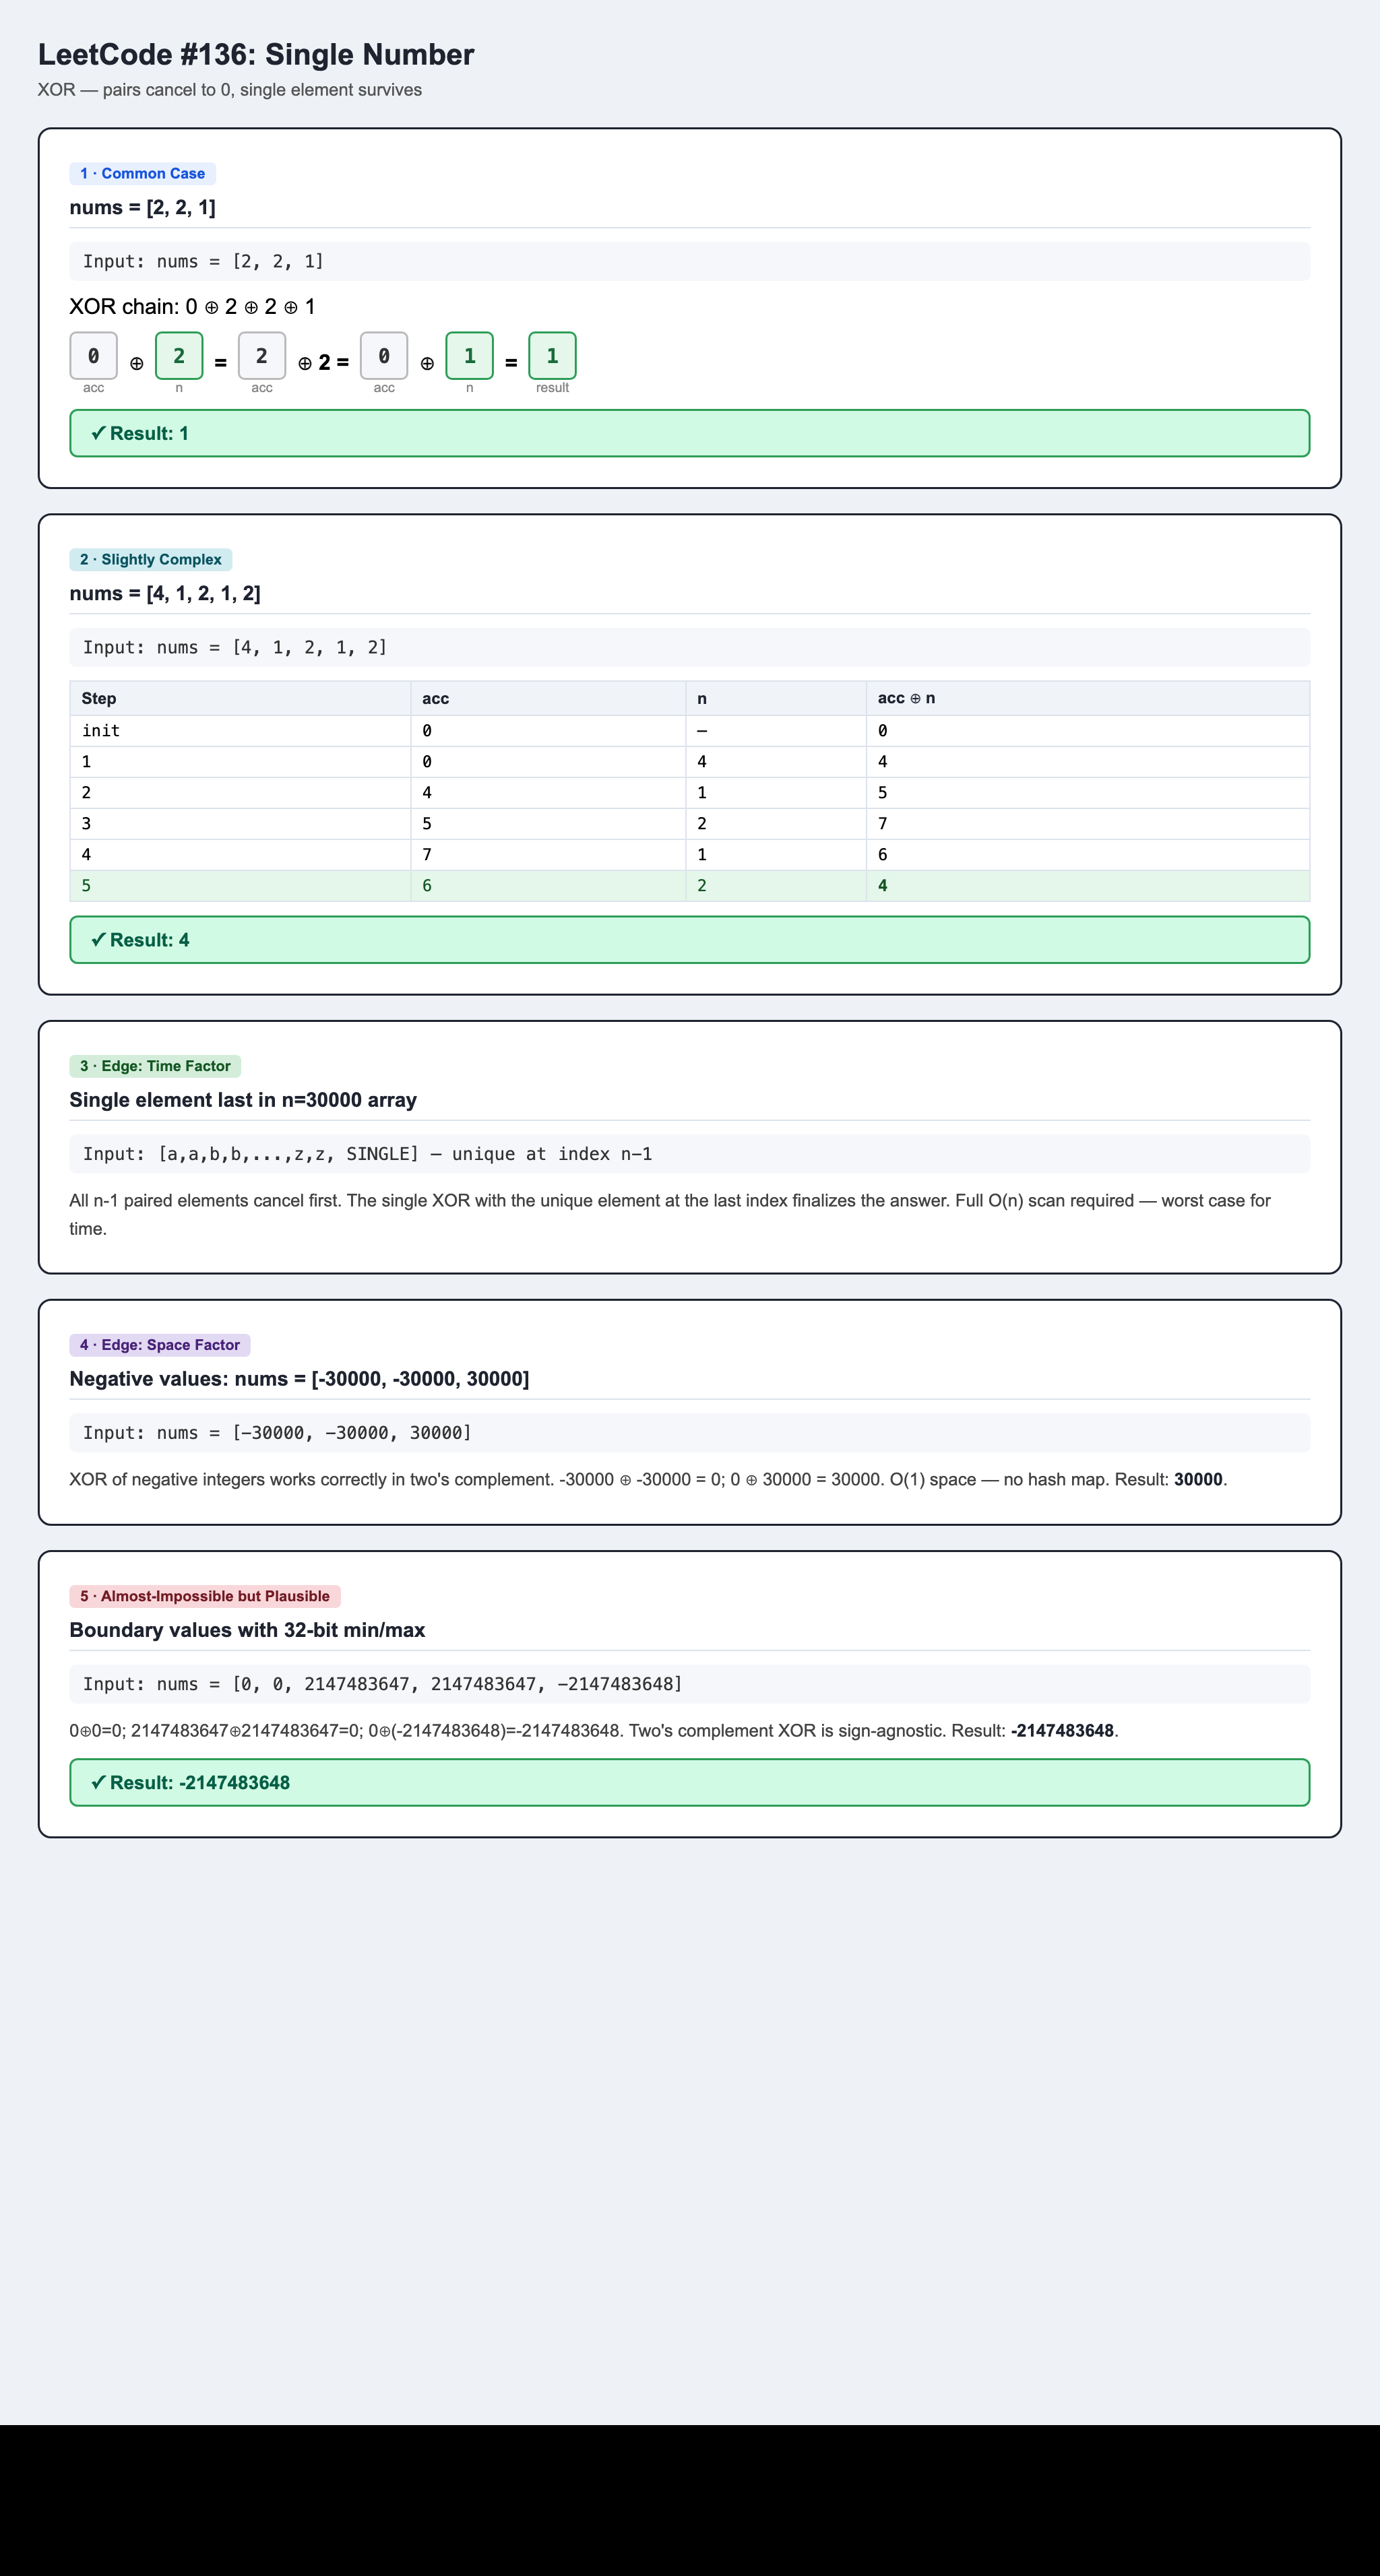